Dataset created and saved to dataset.csv

Accuracy Score: 0.57

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.72      0.66        58
           1       0.48      0.36      0.41        42

    accuracy                           0.57       100
   macro avg       0.55      0.54      0.54       100
weighted avg       0.56      0.57      0.56       100



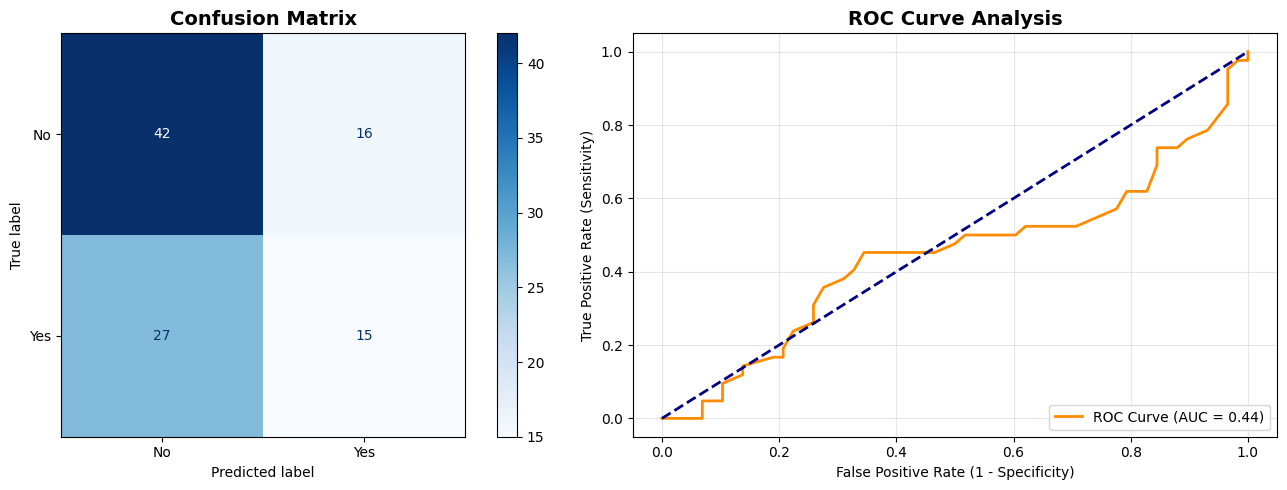

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report,
    accuracy_score
)

# 1. Create Synthetic Customer Dataset
np.random.seed(42)
n_samples = 500

data = {
    'Age': np.random.randint(20, 60, size=n_samples),
    'Salary': np.random.randint(30000, 120000, size=n_samples),
    'Experience_Years': np.random.randint(1, 20, size=n_samples),
    'Purchased': np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])
}

df = pd.DataFrame(data)
df.to_csv('dataset.csv', index=False)
print("Dataset created and saved to dataset.csv")

# 2. Features and Target Variable
X = df[['Age', 'Salary', 'Experience_Years']]
y = df['Purchased']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Predictions & Probabilities
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# 7. Print Evaluation Metrics
print("\nAccuracy Score:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Plot & Save Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve Analysis', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=300)
plt.show()

# 9. Trigger Downloads
from google.colab import files
files.download('dataset.csv')
files.download('confusion_matrix_roc.png')